## Normals to an Ellipse

For the implicit ellipse $F(x,y) = \dfrac{x^2}{a^2} + \dfrac{y^2}{b^2} - 1 = 0$, the **outward normal** at a surface point is the gradient $\nabla F$. The **inward normal** is $-\nabla F$. Normalizing gives unit vectors.

∂F/∂x = (2*x - 2*x0)/a**2
∂F/∂y = (2*y - 2*y0)/b**2
Outward unit normal:
  nx = b**2*(x - x0)/sqrt(a**4*(y - y0)**2 + b**4*(x - x0)**2)
  ny = a**2*(y - y0)/sqrt(a**4*(y - y0)**2 + b**4*(x - x0)**2)

Inward unit normal:
  nx = -b**2*(x - x0)/sqrt(a**4*(y - y0)**2 + b**4*(x - x0)**2)
  ny = -a**2*(y - y0)/sqrt(a**4*(y - y0)**2 + b**4*(x - x0)**2)
Outward normal at (a·cos t, b·sin t):
  nx(t) = 4*(-x0 + 3*cos(t))/sqrt(16*(x0 - 3*cos(t))**2 + 81*(y0 - 2*sin(t))**2)
  ny(t) = 9*(-y0 + 2*sin(t))/sqrt(16*(x0 - 3*cos(t))**2 + 81*(y0 - 2*sin(t))**2)


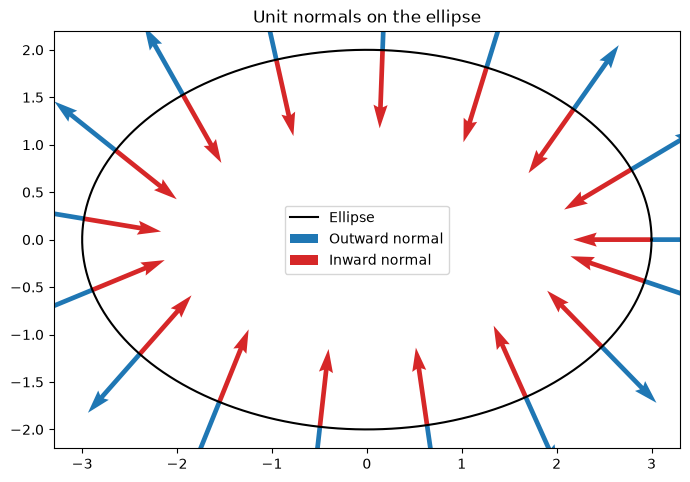

In [2]:
import sympy as sp

# make a elipse:

x, y = sp.symbols('x y')
x0, y0 = sp.symbols('x0 y0')
a, b = sp.symbols('a b', positive=True)
elipse = (x-x0)**2/a**2 + (y-y0)**2/b**2 - 1



# Symbolic gradient (unnormalized outward normal)
grad_x = sp.diff(elipse, x)
grad_y = sp.diff(elipse, y)

print("∂F/∂x =", grad_x)
print("∂F/∂y =", grad_y)

mag = sp.sqrt(grad_x**2 + grad_y**2)

n_out_x = sp.simplify(grad_x / mag)
n_out_y = sp.simplify(grad_y / mag)

n_in_x = -n_out_x
n_in_y = -n_out_y

print("Outward unit normal:")
print("  nx =", n_out_x)
print("  ny =", n_out_y)
print("\nInward unit normal:")
print("  nx =", n_in_x)
print("  ny =", n_in_y)

# Evaluate at a concrete point on the ellipse with a=3, b=2
# Parameterize: x0 = a*cos(t), y0 = b*sin(t)
t = sp.Symbol('t')
a_val, b_val = 3, 2

x0 = a_val * sp.cos(t)
y0 = b_val * sp.sin(t)

nx_eval = n_out_x.subs([(x, x0), (y, y0), (a, a_val), (b, b_val)])
ny_eval = n_out_y.subs([(x, x0), (y, y0), (a, a_val), (b, b_val)])

print("Outward normal at (a·cos t, b·sin t):")
print("  nx(t) =", sp.simplify(nx_eval))
print("  ny(t) =", sp.simplify(ny_eval))

import numpy as np
import matplotlib.pyplot as plt

a_n, b_n = 3.0, 2.0
theta = np.linspace(0, 2 * np.pi, 200)

# Ellipse points
px = a_n * np.cos(theta)
py = b_n * np.sin(theta)

# Normal components (unnormalized gradient, then normalized)
gx = 2 * px / a_n**2
gy = 2 * py / b_n**2
mag_n = np.sqrt(gx**2 + gy**2)
gx, gy = gx / mag_n, gy / mag_n

# Sample every Nth point for arrow clarity
step = 12
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(px, py, 'k-', lw=1.5, label='Ellipse')
ax.quiver(px[::step], py[::step],  gx[::step],  gy[::step],
          color='tab:blue', scale=8, label='Outward normal')
ax.quiver(px[::step], py[::step], -gx[::step], -gy[::step],
          color='tab:red',  scale=8, label='Inward normal')
ax.set_aspect('equal')
ax.legend()
ax.set_title('Unit normals on the ellipse')
plt.tight_layout()
plt.show()

∂F/∂x = -m
∂F/∂y = 1
Outward unit normal:
  nx = -m/sqrt(m**2 + 1)
  ny = 1/sqrt(m**2 + 1)

Inward unit normal:
  nx = m/sqrt(m**2 + 1)
  ny = -1/sqrt(m**2 + 1)


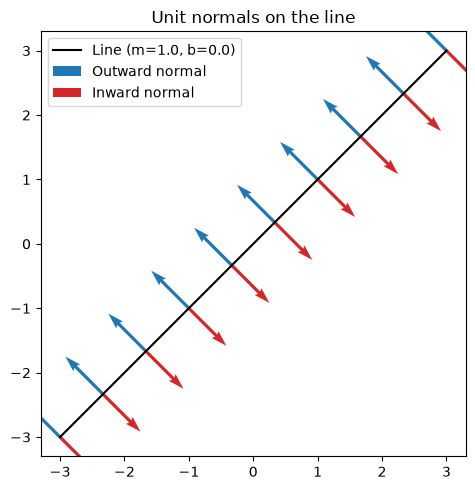

In [3]:
# now the same for a line define as F(x,y) = y - mx - b = 0
x, y = sp.symbols('x y')
m, b = sp.symbols('m b')
line = y - m*x - b

# Gradient (normal vector)
grad_x = sp.diff(line, x)
grad_y = sp.diff(line, y)

print("∂F/∂x =", grad_x)
print("∂F/∂y =", grad_y)

mag = sp.sqrt(grad_x**2 + grad_y**2)

n_out_x = sp.simplify(grad_x / mag)
n_out_y = sp.simplify(grad_y / mag)

n_in_x = -n_out_x
n_in_y = -n_out_y

print("Outward unit normal:")
print("  nx =", n_out_x)
print("  ny =", n_out_y)
print("\nInward unit normal:")
print("  nx =", n_in_x)
print("  ny =", n_in_y)

# Evaluate at concrete values: m=1, b=0  (line y = x)
m_val, b_val = 1.0, 0.0

nx_num = float(n_out_x.subs(m, m_val))
ny_num = float(n_out_y.subs(m, m_val))

# Sample points along the line
x_pts = np.linspace(-3, 3, 10)
y_pts = m_val * x_pts + b_val

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_pts, y_pts, 'k-', lw=1.5, label=f'Line (m={m_val}, b={b_val})')
ax.quiver(x_pts, y_pts,  nx_num,  ny_num,
          color='tab:blue', scale=8, label='Outward normal')
ax.quiver(x_pts, y_pts, -nx_num, -ny_num,
          color='tab:red',  scale=8, label='Inward normal')
ax.set_aspect('equal')
ax.legend()
ax.set_title('Unit normals on the line')
plt.tight_layout()
plt.show()
